In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('california_housing_data.csv')
df.head()

# Info dataset
df.info()

# Statistiche descrittive
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Ho tutti numeri (niente stringhe) non nulli -> niente pulizia

## Outlier

In [12]:
# Calcolo Q1 e Q3
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Mantengo solo i dati senza outlier
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [13]:
# Info dataset
df_clean.info()

# Statistiche descrittive
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16312 entries, 2 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       16312 non-null  float64
 1   HouseAge     16312 non-null  float64
 2   AveRooms     16312 non-null  float64
 3   AveBedrms    16312 non-null  float64
 4   Population   16312 non-null  float64
 5   AveOccup     16312 non-null  float64
 6   Latitude     16312 non-null  float64
 7   Longitude    16312 non-null  float64
 8   MedHouseVal  16312 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000
mean,3.657930,29.447155,5.156007,1.047226,1271.783227,2.865163,35.670947,-119.626930,1.927436
std,1.444641,12.194464,1.043588,0.066569,627.384658,0.624931,2.140620,1.995143,0.943917
min,0.536000,1.000000,2.032738,0.866013,5.000000,1.161290,32.540000,-124.350000,0.149990
25%,2.561150,19.000000,4.426033,1.002732,814.000000,2.437060,33.940000,-121.820000,1.185000
50%,3.494650,30.000000,5.142857,1.043733,1160.000000,2.814886,34.290000,-118.610000,1.775000
75%,4.583300,38.000000,5.850487,1.088686,1637.000000,3.245208,37.730000,-118.030000,2.494000
max,8.011300,52.000000,8.452915,1.239521,3132.000000,4.560748,41.950000,-114.570000,4.822000


## Featuring Engineering

In [14]:
# --- Feature derivate di base ---
# Relazioni dirette tra dimensione della casa, età e popolazione

df_clean["Rooms_per_HouseAge"] = df_clean["AveRooms"] / df_clean["HouseAge"]
# -> quante stanze ci sono mediamente in relazione all’età delle case.
#   Case più nuove con molte stanze potrebbero indicare aree più ricche.

df_clean["Bedrooms_per_Room"] = df_clean["AveBedrms"] / df_clean["AveRooms"]
# -> proporzione di camere da letto sul totale delle stanze.
#   Valori alti indicano case più “familiari”, valori bassi case più spaziose o moderne.

df_clean["Population_per_HouseAge"] = df_clean["Population"] / df_clean["HouseAge"]
# -> popolazione relativa all’età delle case: zone più vecchie ma molto popolate
#   possono avere un mercato immobiliare diverso da zone nuove e meno dense.

df_clean["Bedrooms_per_Person"] = df_clean["AveBedrms"] / df_clean["Population"]
# -> quante camere da letto per abitante medio: misura indiretta di comfort e densità abitativa.


# --- Distanza geografica ---
df_clean["Distance_from_Center"] = np.sqrt((df_clean["Longitude"] + 119.4179)**2 + (df_clean["Latitude"] - 36.7783)**2)
# -> distanza dal centro geografico della California.
#   Serve come proxy per distinguere zone centrali da zone periferiche (che spesso hanno prezzi diversi).


# --- Trasformazioni per ridurre la skewness ---
df_clean["MedInc_log"] = np.log1p(df_clean["MedInc"])
# -> logaritmo del reddito medio per ridurre l’effetto di valori estremi.

df_clean["HouseAge_sqrt"] = np.sqrt(df_clean["HouseAge"])
# -> radice quadrata dell’età della casa: attenua la crescita troppo rapida di case molto vecchie.


# --- Relazioni tra densità e popolazione ---
df_clean["People_per_Room"] = df_clean["Population"] / (df_clean["AveRooms"] + 1e-5)
# -> quante persone mediamente per stanza: misura di sovraffollamento.

df_clean["Rooms_per_Person"] = df_clean["AveRooms"] / (df_clean["Population"] + 1e-5)
# -> opposto di sopra: più alto -> più spazio per persona.

df_clean["Bedrooms_per_Person"] = df_clean["AveBedrms"] / (df_clean["Population"] + 1e-5)
# -> camere da letto per abitante: correlata a comfort abitativo e classe sociale.


# --- Relazioni socio-economiche ---
df_clean["Income_per_HouseAge"] = df_clean["MedInc"] / (df_clean["HouseAge"] + 1)
# -> reddito medio per anno di età della casa:
#   zone con case vecchie ma redditi alti potrebbero indicare quartieri “storici” e costosi.

df_clean["Income_x_HouseAge"] = df_clean["MedInc"] * df_clean["HouseAge"]
# -> interazione diretta reddito × età casa, per catturare effetti combinati.


# --- Interazioni strutturali ---
df_clean["MedInc_x_AveRooms"] = df_clean["MedInc"] * df_clean["AveRooms"]
# -> reddito medio moltiplicato per numero medio di stanze: misura del livello economico + dimensione.

df_clean["MedInc_x_AveBedrms"] = df_clean["MedInc"] * df_clean["AveBedrms"]
# -> simile, ma specifica sulle camere da letto.

df_clean["AveRooms_x_Age"] = df_clean["AveRooms"] * df_clean["HouseAge"]
# -> interazione età × dimensione: case più grandi e vecchie possono comportarsi in modo diverso nel mercato.


# --- Trasformazioni polinomiali leggere ---
df_clean["MedInc_sq"] = df_clean["MedInc"] ** 2
# -> quadrato del reddito medio: cattura effetti non lineari (es. prezzi che crescono più che proporzionalmente al reddito).

df_clean["HouseAge_sq"] = df_clean["HouseAge"] ** 2
# -> quadrato dell’età della casa: utile se il prezzo cala più rapidamente per case molto vecchie.

df_clean["AveRooms_sq"] = df_clean["AveRooms"] ** 2
# -> quadrato del numero medio di stanze: cattura variazioni di prezzo tra case piccole e molto grandi.


# --- Feature geografiche avanzate ---
df_clean["Lat_plus_Lon"] = df_clean["Latitude"] + df_clean["Longitude"]
df_clean["Lat_minus_Lon"] = df_clean["Latitude"] - df_clean["Longitude"]
# -> combinazioni lineari di latitudine e longitudine:
#   i modelli lineari possono così stimare variazioni di prezzo lungo assi geografici (es. nord-sud, est-ovest).

# Creazione di cluster geografici (zone simili per posizione)
from sklearn.cluster import KMeans
coords = df_clean[["Latitude", "Longitude"]]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["GeoCluster"] = kmeans.fit_predict(coords)
# -> assegna ogni riga a una “zona geografica” (1–5), utile per modelli che non gestiscono bene le coordinate continue.


# --- Indicatori binari / non lineari ---
df_clean["Is_Old_House"] = (df_clean["HouseAge"] > df_clean["HouseAge"].median()).astype(int)
# -> 1 se la casa è più vecchia della mediana del dataset.
#   Permette di catturare il “salto” di prezzo tra case vecchie e nuove.

df_clean["Is_High_Income"] = (df_clean["MedInc"] > df_clean["MedInc"].median()).astype(int)
# -> 1 se il reddito medio è sopra la mediana.
#   Aiuta i modelli a distinguere aree ad alto reddito da quelle a basso reddito.


# --- Distanza dalla costa ---
df_clean["Distance_from_Coast"] = np.abs(df_clean["Longitude"] + 122)
# -> Calcola quanto la località è lontana (in gradi longitudinali) dalla costa californiana.
#   La costa ovest si trova intorno a -122, quindi località con valori piccoli sono vicine all’oceano.
#   In California, la vicinanza alla costa spesso aumenta il valore degli immobili.


# --- Densità popolazione geografica ---
df_clean["Pop_density_geo"] = df_clean["Population"] / (
    (df_clean["Latitude"] - df_clean["Latitude"].mean())**2 +
    (df_clean["Longitude"] - df_clean["Longitude"].mean())**2 + 1
)
# -> Misura una densità "spaziale" della popolazione rispetto al centro geografico medio del dataset.
#   Le zone molto popolate e vicine al centro avranno valori più alti.
#   Utile per catturare l’effetto “densità urbana” (più popolazione -> prezzi più alti).


# --- Interazioni reddito × posizione ---
df_clean["Income_x_Lat"] = df_clean["MedInc"] * df_clean["Latitude"]
# -> Combina reddito medio e latitudine:
#   permette al modello di cogliere differenze economiche tra nord e sud della California.

df_clean["Income_x_Lon"] = df_clean["MedInc"] * df_clean["Longitude"]
# -> Combina reddito medio e longitudine:
#   utile per distinguere aree costiere (più a ovest, longitudini minori) da quelle interne.

In [15]:
# Info dataset
df_clean.info()

# Statistiche descrittive
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 16312 entries, 2 to 20639
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MedInc                   16312 non-null  float64
 1   HouseAge                 16312 non-null  float64
 2   AveRooms                 16312 non-null  float64
 3   AveBedrms                16312 non-null  float64
 4   Population               16312 non-null  float64
 5   AveOccup                 16312 non-null  float64
 6   Latitude                 16312 non-null  float64
 7   Longitude                16312 non-null  float64
 8   MedHouseVal              16312 non-null  float64
 9   Rooms_per_HouseAge       16312 non-null  float64
 10  Bedrooms_per_Room        16312 non-null  float64
 11  Population_per_HouseAge  16312 non-null  float64
 12  Bedrooms_per_Person      16312 non-null  float64
 13  Distance_from_Center     16312 non-null  float64
 14  MedInc_log               16

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_HouseAge,...,AveRooms_sq,Lat_plus_Lon,Lat_minus_Lon,GeoCluster,Is_Old_House,Is_High_Income,Distance_from_Coast,Pop_density_geo,Income_x_Lat,Income_x_Lon
count,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,...,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000,16312.000000
mean,3.657930,29.447155,5.156007,1.047226,1271.783227,2.865163,35.670947,-119.626930,1.927436,0.239425,...,27.673415,-83.955983,155.297877,1.001839,0.487433,0.500000,2.530349,205.096701,130.238691,-437.615580
std,1.444641,12.194464,1.043588,0.066569,627.384658,0.624931,2.140620,1.995143,0.943917,0.231972,...,10.981325,0.768776,4.066287,1.146921,0.499857,0.500015,1.791464,207.427929,51.491604,173.075777
min,0.536000,1.000000,2.032738,0.866013,5.000000,1.161290,32.540000,-124.350000,0.149990,0.041715,...,4.132024,-85.870000,147.400000,0.000000,0.000000,0.000000,0.000000,0.165149,17.554000,-980.524974
25%,2.561150,19.000000,4.426033,1.002732,814.000000,2.437060,33.940000,-121.820000,1.185000,0.125075,...,19.589769,-84.420000,151.970000,0.000000,0.000000,0.000000,0.520000,80.565935,91.438980,-548.192860
50%,3.494650,30.000000,5.142857,1.043733,1160.000000,2.814886,34.290000,-118.610000,1.775000,0.170932,...,26.448980,-84.180000,152.990000,1.000000,0.000000,0.500000,3.390000,144.206589,123.718439,-417.058207
75%,4.583300,38.000000,5.850487,1.088686,1637.000000,3.245208,37.730000,-118.030000,2.494000,0.273300,...,34.228194,-83.550000,159.710000,1.000000,1.000000,1.000000,3.970000,248.109505,162.705937,-306.559496
max,8.011300,52.000000,8.452915,1.239521,3132.000000,4.560748,41.950000,-114.570000,4.822000,5.533333,...,71.451769,-79.330000,166.140000,4.000000,1.000000,1.000000,7.430000,2453.346073,306.752677,-61.436320


## Matrice di correlazione

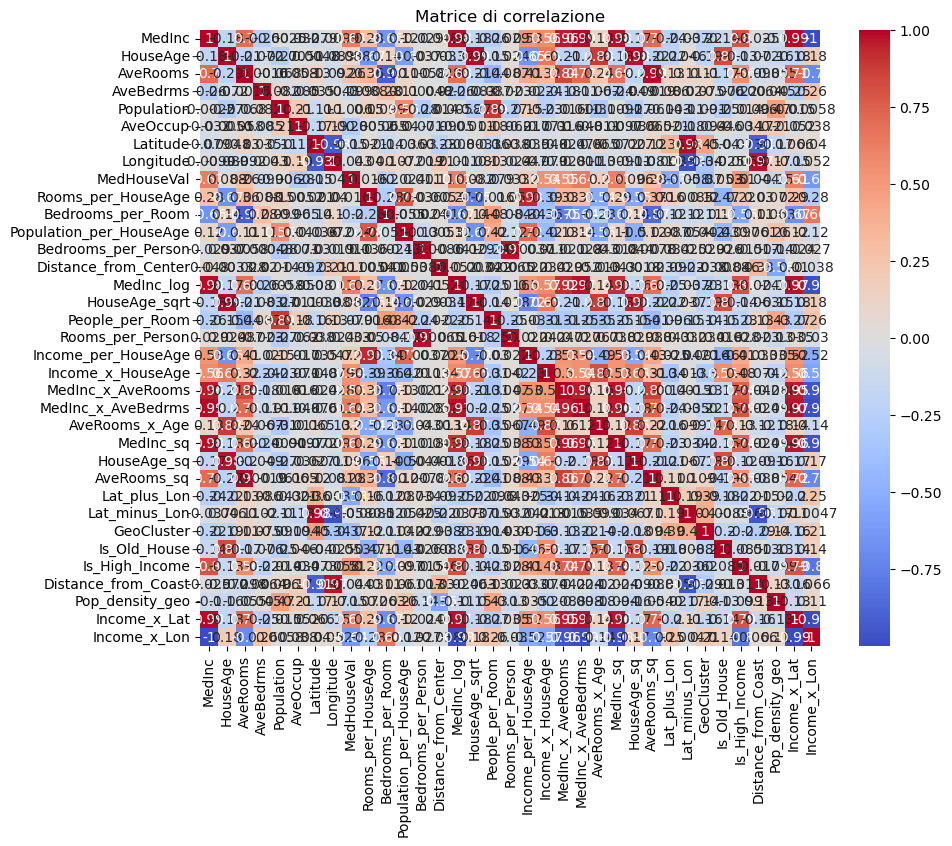

In [16]:
# Calcolo
corr = df_clean.corr(numeric_only=True)
corr

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice di correlazione")

plt.show()
# MedInc è molto correlato a MedHouseVal (forte segno +)
# AveBedrms cresce fortemente con AveRooms
# Latitude/Longitude -> gradienti geografici

In [17]:
display(corr)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_HouseAge,...,AveRooms_sq,Lat_plus_Lon,Lat_minus_Lon,GeoCluster,Is_Old_House,Is_High_Income,Distance_from_Coast,Pop_density_geo,Income_x_Lat,Income_x_Lon
MedInc,1.000000,-0.181014,0.698658,-0.256522,-0.002466,-0.031503,-0.078629,-0.009936,0.632971,0.284833,...,0.710105,-0.244724,-0.036517,-0.220993,-0.139153,0.804407,-0.024785,-0.103181,0.987782,-0.998963
HouseAge,-0.181014,1.000000,-0.209684,-0.071658,-0.272499,-0.005069,0.004834,-0.088993,0.087911,-0.669724,...,-0.221328,-0.217496,0.046210,-0.194661,0.834447,-0.133045,-0.071505,-0.155474,-0.179178,0.176889
AveRooms,0.698658,-0.209684,1.000000,-0.001579,-0.067882,0.057669,0.131869,-0.092256,0.260237,0.356873,...,0.990569,0.127758,0.114686,0.110168,-0.174600,0.556880,-0.098199,-0.055429,0.711974,-0.700312
AveBedrms,-0.256522,-0.071658,-0.001579,1.000000,0.082117,-0.085343,0.034775,-0.004277,-0.099079,0.088230,...,0.001873,0.085729,0.020405,0.075072,-0.076436,-0.223426,0.006420,0.044550,-0.251855,0.255983
Population,-0.002466,-0.272499,-0.067882,0.082117,1.000000,0.209546,-0.113037,0.104769,-0.005995,0.152374,...,-0.060784,-0.042849,-0.110912,-0.091244,-0.249139,-0.013672,0.096072,0.472128,-0.015002,0.005823
AveOccup,-0.031503,-0.005069,0.057669,-0.085343,0.209546,1.000000,-0.166071,0.186429,-0.275504,-0.005236,...,0.064857,0.021410,-0.178897,-0.094447,0.046469,-0.034085,0.171516,0.209835,-0.051629,0.038052
Latitude,-0.078629,0.004834,0.131869,0.034775,-0.113037,-0.166071,1.000000,-0.933286,-0.150479,0.021298,...,0.115793,0.362371,0.984352,0.452149,-0.040349,-0.072952,-0.910850,-0.166245,0.066287,0.039782
Longitude,-0.009936,-0.088993,-0.092256,-0.004277,0.104769,0.186429,-0.933286,1.000000,-0.043103,0.040250,...,-0.081465,-0.003470,-0.981966,-0.335306,-0.025453,-0.005837,0.971345,0.170832,-0.149614,0.052282
MedHouseVal,0.632971,0.087911,0.260237,-0.099079,-0.005995,-0.275504,-0.150479,-0.043103,1.000000,0.016494,...,0.284524,-0.530863,-0.058068,-0.373214,0.053450,0.506971,-0.044441,-0.150461,0.614789,-0.635012
Rooms_per_HouseAge,0.284833,-0.669724,0.356873,0.088230,0.152374,-0.005236,0.021298,0.040250,0.016494,1.000000,...,0.368180,0.163761,-0.008536,0.119249,-0.467433,0.223731,0.029863,0.071542,0.285478,-0.281836


# DATASET: df_clean

# Il processo "Sotto il cofano" (Cross-Validation)

1. Caricamento e Pulizia Dati...
   -> Dataset pulito: (16312, 35)
2. Generazione Feature 'Combo' (Multiplicazioni, Divisioni, Log)...
   -> Generazione combinazioni su 34 colonne base...
   -> Totale Feature Generate: 1752
3. Selezione Feature tramite CPU...
   -> Feature Sopravvissute: 727
   -> Esempio Top Feature scelte: ['Latitude', 'Distance_from_Center', 'Lat_plus_Lon', 'Lat_minus_Lon', 'Dist_SF']...

Set Ottimizzazione: Train=1304, Validation=11745

4. Tuning Iperparametri VELOCE (Hold-out validation con CPU)...
 -> Optimizing XGBoost...
 -> Optimizing CatBoost (fast)...
 -> Optimizing LightGBM...

BEST VAL RMSE:
XGB: 0.4486
CAT: 0.4461
LGBM: 0.4530

5. Addestramento Stacking Ensemble Finale (su set completo)...

 RISULTATI FINALI (CODICE AGGIORNATO)
 RMSE: 0.35717
 R^2 : 0.85406
 Tempo Totale: 3373.39 sec


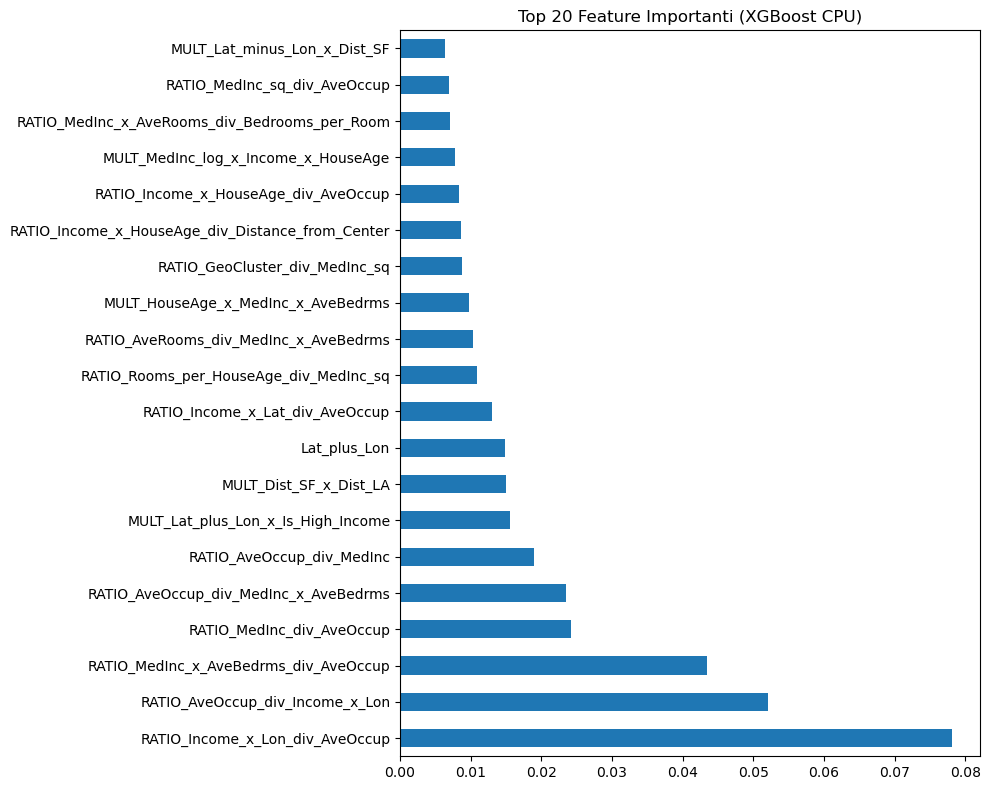

Exception ignored in: <function ResourceTracker.__del__ at 0x104dedbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1076d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1076cdbc0>
Traceback (most recent call last

In [ ]:
import numpy as np
import pandas as pd
import optuna
import warnings
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectFromModel

# Modelli
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor

# Configurazione
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. CARICAMENTO E PULIZIA DATI
# ---------------------------------------------------------
print("1. Caricamento e Pulizia Dati...")
start_global = time.time()

X = df_clean.drop("MedHouseVal", axis=1)
y = df_clean["MedHouseVal"]

df = pd.concat([X, y], axis=1)

# Rimuovi il cap a 5.0 (valore massimo del dataset originale che crea distorsioni)
df = df[df['MedHouseVal'] < 5.0]

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    indices_to_drop = []
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_clean[(df_clean[col] < Q1 - 2.0*IQR) | (df_clean[col] > Q3 + 2.0*IQR)].index
        indices_to_drop.extend(outliers)
    return df_clean.drop(list(set(indices_to_drop)))

cols_clean = ['AveRooms', 'AveBedrms', 'AveOccup', 'MedInc']
df = remove_outliers_iqr(df, cols_clean)
print(f"   -> Dataset pulito: {df.shape}")

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING MASSIVA
# ---------------------------------------------------------
print("2. Generazione Feature 'Combo' (Multiplicazioni, Divisioni, Log)...")

def generate_comprehensive_features(df_input, cols_to_combine):
    df_eng = df_input.copy()
    math_cols = [c for c in cols_to_combine if c not in ['Latitude', 'Longitude', 'Geo_Cluster']]
    
    print(f"   -> Generazione combinazioni su {len(math_cols)} colonne base...")

    # A. LOGARITMI
    for col in math_cols:
        if df_eng[col].min() >= 0:
            df_eng[f'LOG_{col}'] = np.log1p(df_eng[col])

    # B. MOLTIPLICAZIONI
    for col1, col2 in itertools.combinations(math_cols, 2):
        col_name = f'MULT_{col1}_x_{col2}'
        df_eng[col_name] = df_eng[col1] * df_eng[col2]

    # C. DIVISIONI / RAPPORTI
    for col1, col2 in itertools.permutations(math_cols, 2):
        col_name = f'RATIO_{col1}_div_{col2}'
        df_eng[col_name] = df_eng[col1] / (df_eng[col2] + 1e-5)

    return df_eng

# --- Geo Features Base ---
sf_coords = (37.7749, -122.4194)
la_coords = (34.0522, -118.2437)
df['Dist_SF'] = np.sqrt((df['Latitude'] - sf_coords[0])**2 + (df['Longitude'] - sf_coords[1])**2)
df['Dist_LA'] = np.sqrt((df['Latitude'] - la_coords[0])**2 + (df['Longitude'] - la_coords[1])**2)

coords = df[['Latitude', 'Longitude']]
# KMeans (Cluster geografici)
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df['Geo_Cluster'] = kmeans.fit_predict(StandardScaler().fit_transform(coords))

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

cols_for_math = [c for c in X.columns if c != 'Geo_Cluster']
X_full = generate_comprehensive_features(X, cols_for_math)

# Pulizia inf/nan generati dalle divisioni
X_full.replace([np.inf, -np.inf], np.nan, inplace=True)
X_full.fillna(0, inplace=True)

print(f"   -> Totale Feature Generate: {X_full.shape[1]}")

# ---------------------------------------------------------
# 3. IL GIUDICE: SELEZIONE FEATURE CON XGBOOST CPU
# ---------------------------------------------------------
print("3. Selezione Feature tramite CPU...")

scaler = RobustScaler()
# Nota: La selezione feature non necessita di early stopping complesso
selector_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    verbose=0
)
selector_model.fit(X_full, y)

selection = SelectFromModel(selector_model, prefit=True, threshold='1.25*median')

X_selected = X_full.loc[:, selection.get_support()]
print(f"   -> Feature Sopravvissute: {X_selected.shape[1]}")

selected_names = X_full.columns[selection.get_support()]
print(f"   -> Esempio Top Feature scelte: {list(selected_names[:5])}...")

X_train_full, X_test, y_train_full, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# =========================================================
# === SPLIT PER OPTUNA VELOCE (HOLD-OUT) ===
# =========================================================
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train_full, y_train_full, test_size=0.9, random_state=42
)
print(f"\nSet Ottimizzazione: Train={X_opt_train.shape[0]}, Validation={X_opt_val.shape[0]}")

# ---------------------------------------------------------
# 4. OPTUNA SUPER VELOCE (Aggiornato per nuove API)
# ---------------------------------------------------------
print("\n4. Tuning Iperparametri VELOCE (Hold-out validation con CPU)...")
N_TRIALS = 5 # con 50 ci mette ore

# --- A. XGBoost (CPU - Aggiornato) ---
def objective_xgb(trial):
    params = {
        'n_estimators': 1000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42,
        'eval_metric': 'rmse',
        # FIX: early_stopping_rounds va qui nel costruttore per le nuove versioni
        'early_stopping_rounds': 100 
    }
    
    # Inizializza con early_stopping_rounds
    model = XGBRegressor(**params)
    

    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        verbose=False # In XGBoost 2.0+ a volte verbose in fit è deprecato, ma False di solito passa
    )
    
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print(" -> Optimizing XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

# --- B. CatBoost (CPU) ---
# ---------------------
# CatBoost: versione rapida e stabile per tuning
# ---------------------
from optuna.integration import CatBoostPruningCallback

def objective_cat_fast(trial):
    params = {
        'iterations': 1000,                       # ridotto per tuning
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'task_type': 'CPU',
        'thread_count': 1,                        # ESSENZIALE: evita deadlock con optuna parallel
        'verbose': 0,
        'allow_writing_files': False,
        'random_seed': 42,
        'eval_metric': 'RMSE',
        'od_type': 'Iter',                        # early stopping by iterations
        'od_wait': 30
    }
    model = CatBoostRegressor(**params)

    # Callback per pruning (integrazione Optuna <-> CatBoost)
    pruning_cb = CatBoostPruningCallback(trial, "RMSE")

    model.fit(
        X_opt_train, y_opt_train,
        eval_set=(X_opt_val, y_opt_val),
        early_stopping_rounds=30,
        verbose=False,
        callbacks=[pruning_cb]
    )
    preds = model.predict(X_opt_val)
    return np.sqrt(mean_squared_error(y_opt_val, preds))

print(" -> Optimizing CatBoost (fast)...")
study_cat = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
# Esegui IN SERIE per sicurezza (n_jobs=1)
study_cat.optimize(objective_cat_fast, n_trials=N_TRIALS, n_jobs=1)

# --- C. LightGBM (Hybrid - Aggiornato) ---
def objective_lgbm(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 30, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.95),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.95),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
        'device': 'cpu',
        'n_jobs': -1,
        'verbosity': -1, # Usa verbosity qui invece di verbose
        'random_state': 42,
        'metric': 'rmse'
    }
    
    try:
        model = LGBMRegressor(**params)
        # FIX: Usa callbacks espliciti, rimuovi early_stopping_rounds dagli argomenti diretti
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=100, verbose=False), log_evaluation(period=0)]
        )
        preds = model.predict(X_opt_val)
        return np.sqrt(mean_squared_error(y_opt_val, preds))
    
    except Exception as e:
        # Fallback CPU se CPU non va o errore specifico
        # print(f"LGBM CPU Error: {e}") 
        params['device'] = 'cpu'
        params['n_jobs'] = -1 
        model = LGBMRegressor(**params)
        model.fit(
            X_opt_train, y_opt_train,
            eval_set=[(X_opt_val, y_opt_val)],
            eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=100, verbose=False), log_evaluation(period=0)]
        )
        preds = model.predict(X_opt_val)
        return np.sqrt(mean_squared_error(y_opt_val, preds))

print(" -> Optimizing LightGBM...")
study_lgbm = optuna.create_study(direction='minimize')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

print(f"\nBEST VAL RMSE:")
print(f"XGB: {study_xgb.best_value:.4f}")
print(f"CAT: {study_cat.best_value:.4f}")
print(f"LGBM: {study_lgbm.best_value:.4f}")

# ---------------------------------------------------------
# 5. STACKING FINALE (Ensemble)
# ---------------------------------------------------------
print("\n5. Addestramento Stacking Ensemble Finale (su set completo)...")

# Recuperiamo i migliori parametri 
best_xgb_params = study_xgb.best_params
# Assicuriamoci che non ci siano parametri di fit residui
best_xgb_params.update({
    'tree_method': 'hist', 'n_jobs': -1, 
    'random_state': 42, 'early_stopping_rounds': None # Disabilita early stopping per il fit finale
})

best_cat_params = study_cat.best_params
best_cat_params.update({
    'task_type': 'CPU', 'devices': '0', 'verbose': 0, 
    'allow_writing_files': False, 'random_state': 42
})

best_lgbm_params = study_lgbm.best_params
if study_lgbm.best_params.get('device') == 'cpu':
    best_lgbm_params.update({'n_jobs': -1, 'verbosity': -1, 'random_state': 42})
else:
    best_lgbm_params.update({'device': 'cpu', 'n_jobs': -1, 'verbosity': -1, 'random_state': 42})

estimators = [
    ('xgb', XGBRegressor(**best_xgb_params)),
    ('cat', CatBoostRegressor(**best_cat_params)),
    ('lgbm', LGBMRegressor(**best_lgbm_params))
]

# Stacking Regressor non supporta nativamente early stopping nei sotto-modelli
# durante il cross-validation interno in modo semplice, quindi usiamo n_estimators ottimizzati
# (Nota: idealmente dovresti settare n_estimators al valore ottimo trovato durante Optuna, 
# ma qui li lasciamo alti o default per lo stacking standard)

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=3,
    n_jobs= -1 
)

stacking.fit(X_train_full, y_train_full)

# ---------------------------------------------------------
# 6. VALUTAZIONE FINALE
# ---------------------------------------------------------
y_pred = stacking.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)
total_time = time.time() - start_global

print(f"\n==========================================")
print(f" RISULTATI FINALI (CODICE AGGIORNATO)")
print(f"==========================================")
print(f" RMSE: {final_rmse:.5f}")
print(f" R^2 : {final_r2:.5f}")
print(f" Tempo Totale: {total_time:.2f} sec")
print(f"==========================================")

# Plot veloce importanza feature (su XGBoost)
final_xgb = XGBRegressor(**best_xgb_params)
final_xgb.fit(X_train_full, y_train_full)
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(final_xgb.feature_importances_, index=X_train_full.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importanti (XGBoost CPU)")
plt.tight_layout()
plt.show()